In [1]:
import pandas as pd

#load the data
hist_data=pd.read_csv("historical_data.csv")
sentiment_data=pd.read_csv("fear_greed_index.csv")

print(f"historical_data,  no_rows={hist_data.shape[0]}, no_columns={hist_data.shape[1]}")
print(f"sentiment_data,  no_rows={sentiment_data.shape[0]}, no_columns={sentiment_data.shape[1]}")

# (no missing value found after running the code below)
# print(hist_data.isnull().sum())
# print(sentiment_data.isnull().sum())

#(no duplicated value found after running the code below)
# print(hist_data.duplicated().sum())
# print(sentiment_data.duplicated().sum())

#created a new column 'TradeDate' in historical_data by converting the 'Timestamp IST' column to datetime format and extracting the date part
hist_data['Timestamp IST'] = pd.to_datetime(hist_data['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist_data['TradeDate'] = hist_data['Timestamp IST'].dt.date

sentiment_data['date'] = pd.to_datetime(sentiment_data['date']).dt.date

merged_df = pd.merge(hist_data, sentiment_data, left_on='TradeDate', right_on='date', how='left')



# Drop redundant date column and save the result
merged_df.drop(columns=['date'], inplace=True)
merged_df.to_csv('merged_trading_data.csv', index=False)


# found 6 rows having NaN values in the merged dataframe after running the code below
# print(merged_df.isnull().sum())
# print(merged_df.duplicated().sum())



historical_data,  no_rows=211224, no_columns=16
sentiment_data,  no_rows=2644, no_columns=4


  classification     segment     avg_pnl  win_rate  size_tokens
0   Extreme Fear    Frequent   34.163353  0.373683  1673.915029
1   Extreme Fear  Infrequent   35.941979  0.359077  1683.310369
2  Extreme Greed    Frequent   62.870911  0.478898  8937.085293
3  Extreme Greed  Infrequent  103.264685  0.366653  8095.181729
4           Fear    Frequent   51.323784  0.424893  2676.732997
5           Fear  Infrequent   80.835791  0.383848  5819.406007
6          Greed    Frequent   25.004641  0.382192  4774.395547
7          Greed  Infrequent  210.210287  0.409714  4157.690041
8        Neutral    Frequent   34.579701  0.399800  3995.579238
9        Neutral  Infrequent   31.845656  0.371566  7893.747864


C:\Users\91909\AppData\Local\Temp\ipykernel_17272\3438725765.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_stats, x='classification', y='avg_pnl', palette='RdYlGn')
C:\Users\91909\AppData\Local\Temp\ipykernel_17272\3438725765.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_stats, x='classification', y='win_rate', palette='RdYlGn')
C:\Users\91909\AppData\Local\Temp\ipykernel_17272\3438725765.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trader_stats, x='segment', y='total_pnl', palette='Bl

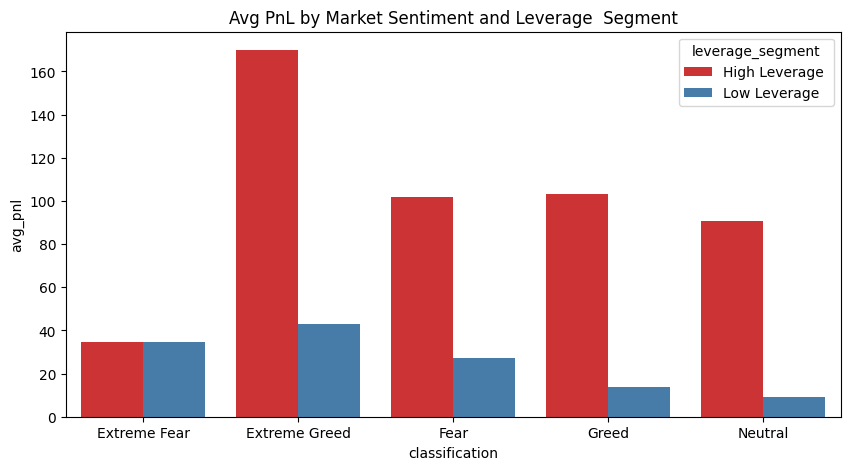

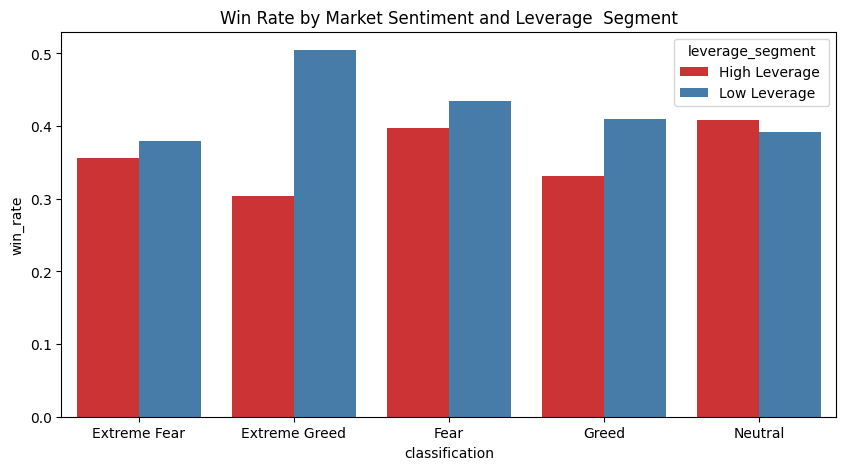

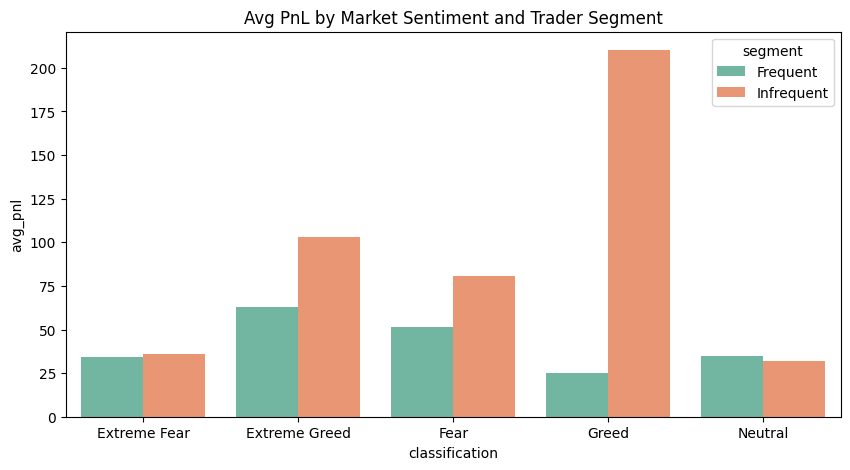

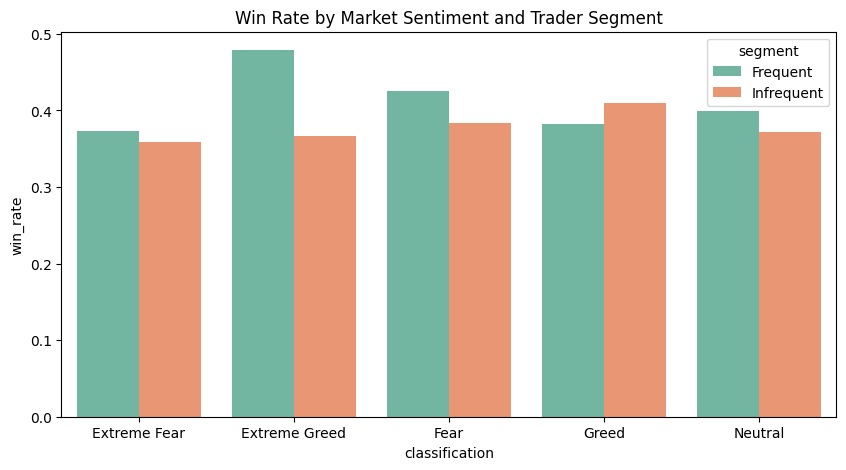

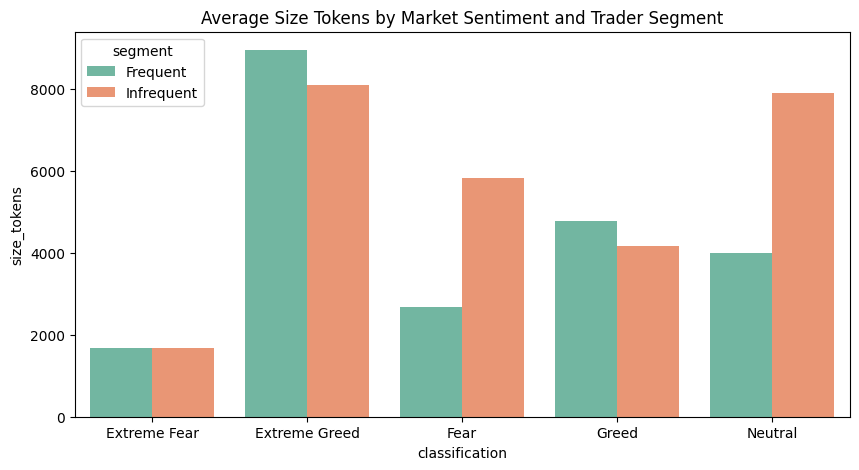

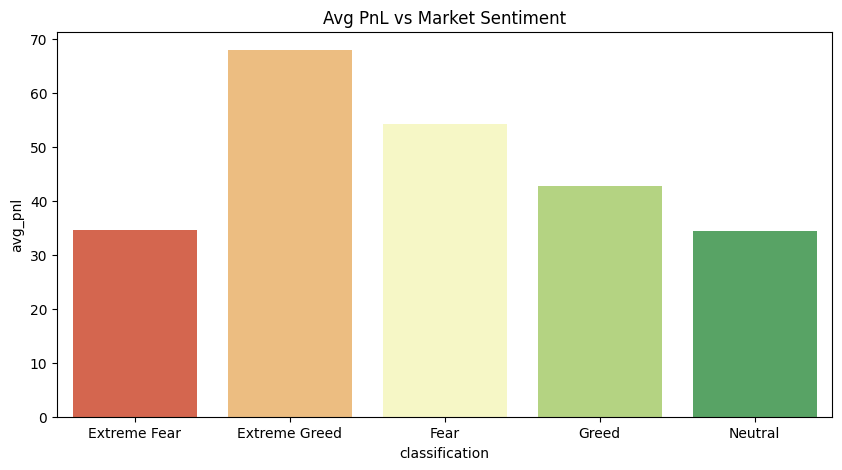

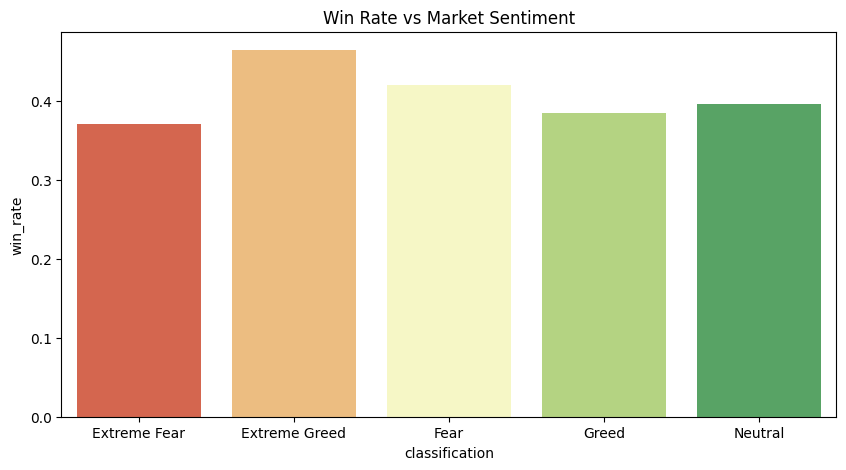

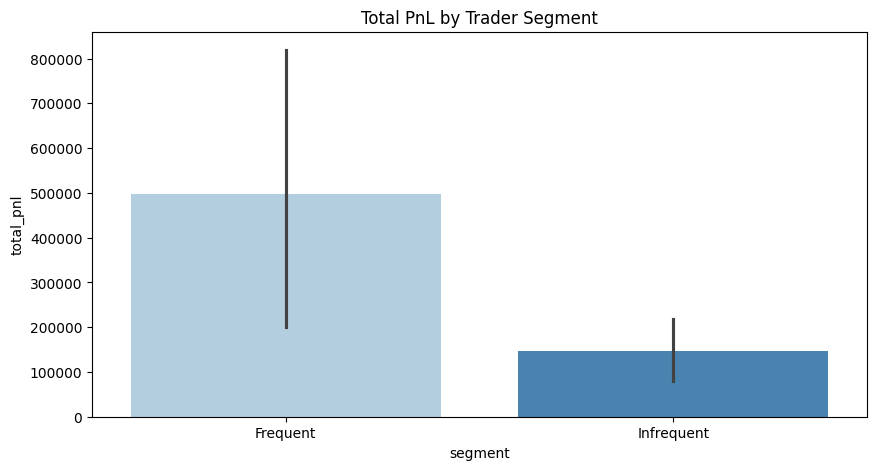

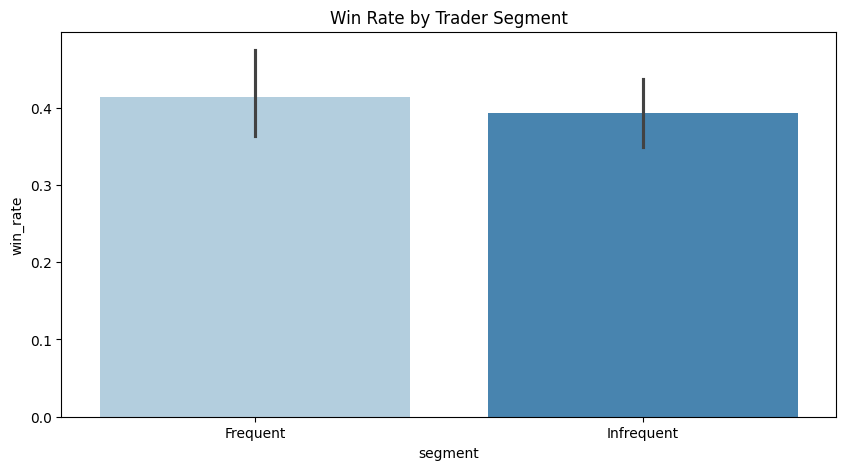

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("merged_trading_data.csv")
df['is_win']= df['Closed PnL'] > 0

# calculate win rate and average PnL for each sentiment classification
sentiment_stats = df.groupby('classification').agg(
    win_rate=('is_win', 'mean'),
    avg_pnl=('Closed PnL', 'mean')
).reset_index()

# calculate total trades and total PnL for each trader
trader_stats = df.groupby('Account').agg(
    trade_count=('Trade ID', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean')
).reset_index()

# segment traders into 'Frequent' and 'Infrequent' based on the median trade count
median_val = trader_stats['trade_count'].median()
trader_stats['segment'] = trader_stats['trade_count'].apply(lambda x: 'Frequent' if x > median_val else 'Infrequent')

#merge the trader segment information back to the main dataframe
df = df.merge(
    trader_stats[['Account', 'segment']],
    on='Account',
    how='left'
)

# calculate average PnL for each sentiment classification and trader segment
grouped = df.groupby(['classification', 'segment']).agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    size_tokens=('Size Tokens', 'mean')
).reset_index()

print(grouped)

#incorperating leverage proxy 
leverage_proxy = df.groupby('Account')['Size USD'].mean().reset_index()

median_size = leverage_proxy['Size USD'].median()
leverage_proxy['leverage_segment'] = leverage_proxy['Size USD'].apply(
    lambda x: 'High Leverage ' if x > median_size else 'Low Leverage '
)
df = pd.merge(df, leverage_proxy[['Account', 'leverage_segment']], on='Account', how='left')


grouped_2 = df.groupby(['classification', 'leverage_segment']).agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    size_tokens=('Size Tokens', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=grouped_2, x='classification', y='avg_pnl', hue='leverage_segment', palette='Set1')
plt.title('Avg PnL by Market Sentiment and Leverage  Segment')
plt.savefig('pnl_by_sentiment_and_leverage_segment.png')

plt.figure(figsize=(10, 5))
sns.barplot(data=grouped_2, x='classification', y='win_rate', hue='leverage_segment', palette='Set1')
plt.title('Win Rate by Market Sentiment and Leverage  Segment')
plt.savefig('win_rate_by_sentiment_and_leverage_segment.png')


plt.figure(figsize=(10, 5))
sns.barplot(data=grouped, x='classification', y='avg_pnl', hue='segment', palette='Set2')
plt.title('Avg PnL by Market Sentiment and Trader Segment')
plt.savefig('pnl_by_sentiment_and_segment.png')

plt.figure(figsize=(10, 5))
sns.barplot(data=grouped, x='classification', y='win_rate', hue='segment', palette='Set2')
plt.title('Win Rate by Market Sentiment and Trader Segment')
plt.savefig('win_rate_by_sentiment_and_segment.png')

plt.figure(figsize=(10, 5))
sns.barplot(data=grouped, x='classification', y='size_tokens', hue='segment', palette='Set2')
plt.title('Average Size Tokens by Market Sentiment and Trader Segment')
plt.savefig('size_tokens_by_sentiment_and_segment.png')


plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_stats, x='classification', y='avg_pnl', palette='RdYlGn')
plt.title('Avg PnL vs Market Sentiment')
plt.savefig('pnl_vs_sentiment.png')

plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_stats, x='classification', y='win_rate', palette='RdYlGn')
plt.title('Win Rate vs Market Sentiment')
plt.savefig('win_rate_vs_sentiment.png')


plt.figure(figsize=(10, 5))
sns.barplot(data=trader_stats, x='segment', y='total_pnl', palette='Blues')
plt.title('Total PnL by Trader Segment')
plt.savefig('pnl_by_trader_segment.png')

plt.figure(figsize=(10, 5))
sns.barplot(data=trader_stats, x='segment', y='win_rate', palette='Blues')
plt.title('Win Rate by Trader Segment')
plt.savefig('win_rate_by_trader_segment.png')

#Report

1.performance  differ between Fear vs Greed days
->Yes the performance differ, for frequent trader's the avg PnL increase for a fear day than that of greedy day,
for infrequent traders, people with greedy sentiment actually have a higher Pnl than people with fear sentiment
->Win rate is almost same for both the greedy and fear days
->traders tend to have a higher position size on greedy day than fear days

2.Do traders behavior  based on sentiment
-> people with neutral sentiment have more frequent trades than infrequent ones, while for greedy sentiment they are more infrequent which is expected.
-> in general , extremely greedy traders have a higher position size than people with extrem fear sentiment
-> in all the 5 sentiments, frequent traders have a higher win rate (PnL>0) 

3.high leverage vs low leverage
->high leverage traders have high avg Pnl but low leverage traders have higher win rate

4.Frequency base on sentiment
-> traders are more frequent on greedy/extremely greedy days and are much more infrequent on neutral days
-> overall , frequent traders have more avg PnL than infrequent ones
-> overall , there is not much difference in win_rate based on frequency alone







#Strategy

Strategy1 :
On extremely fear days, both high and low leverage have equal avg PnL, keep leverage low while keeping frequence of trades to be hight, still will maximize the win rate.

Same can be followed on extremely greedy days, as both these factors support win rate.

Strategy2:
on greedy days, infrequent traders have both higher avg PnL and higher win rate, leverage can be kept high(5% reduction in win rate for 800% increase in avg PnL).


In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate metrics per Account
trader_features = df.groupby('Account').agg({
    'Closed PnL': ['mean', 'sum'],
    'Size USD': 'mean',
    'Trade ID': 'count'
})

# Normalize and Cluster
scaler = StandardScaler()
X = scaler.fit_transform(trader_features)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
trader_features['Archetype'] = kmeans.labels_



# Clusters
#cluster 0: high avg PnL, high total PnL, large size, many trades
#cluster 1: low avg PnL, low total PnL, small size
#cluster 2: medium avg PnL, medium total PnL, medium size    

#in summary
#cluster:0 good trader
#cluster 1: bad trader
#cluster 2: average trader



In [4]:
print(df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'TradeDate', 'timestamp', 'value', 'classification',
       'is_win', 'segment', 'leverage_segment'],
      dtype='str')


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

daily_data = df.groupby(['Account', 'TradeDate', 'classification'])['Closed PnL'].sum().reset_index()

daily_data = daily_data.sort_values(['Account', 'TradeDate'])

#we will use this as lables (y values)
daily_data['next_day_win'] = (
    daily_data.groupby('Account')['Closed PnL'].shift(-1) > 0
).astype(int)

daily_data = daily_data.dropna()

daily_data = pd.get_dummies(daily_data, columns=['classification'])

X = daily_data.drop(columns=['next_day_win', 'Account', 'TradeDate'])
y = daily_data['next_day_win']

# Split into Training and Testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Check Accuracy
predictions = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.2%}")

Model Accuracy: 59.40%
